Loading and cleaning data...

Running WITHOUT storage (CO2 cap = 2 Mt)...


C:\Users\kusha\AppData\Local\Temp\ipykernel_18172\2334222746.py:165: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n_no.optimize(solver_name='highs')
Index(['Czech Republic'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 226.58it/s]
INFO:linopy.io: Writing time: 0.09s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43805 primals, 96366 duals
Objective: 5.33e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.
C:\Users\

Running WITH storage (CO2 cap = 2 Mt)...


Index(['battery', 'hydrogen'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 269.50it/s]
INFO:linopy.io: Writing time: 0.2s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 96367 primals, 219008 duals
Objective: 4.50e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.



PART C — RESULTS SUMMARY  (CO2 cap = 2 Mt)

Technology         Without Storage    With Storage
----------------------------------------------------
solar                  20969.1 MW        27161.6 MW  (+6192 MW)
onshorewind            34523.2 MW        18698.9 MW  (-15824 MW)
gas                     9638.3 MW         6557.2 MW  (-3081 MW)
nuclear                   -0.0 MW           -0.0 MW  (+0 MW)
coal                      -0.0 MW           -0.0 MW  (+0 MW)

--- Storage Capacities ---
  battery     :   9238.9 MW  |    36955.6 MWh  | RTE=90%  | ~198 cycles/yr
  hydrogen    :    348.4 MW  |    58534.0 MWh  | RTE=35%  | ~8 cycles/yr

--- System Cost ---
  Without storage : 5332.59  M EUR/year
  With storage    : 4497.30  M EUR/year
  Change          : -835.29 M EUR/year  (-15.7%)

--- Annual Curtailment ---
  Without storage : 37.04  TWh curtailed
  With storage    : 10.10  TWh curtailed
  Reduction       : 26.95 TWh saved by storage


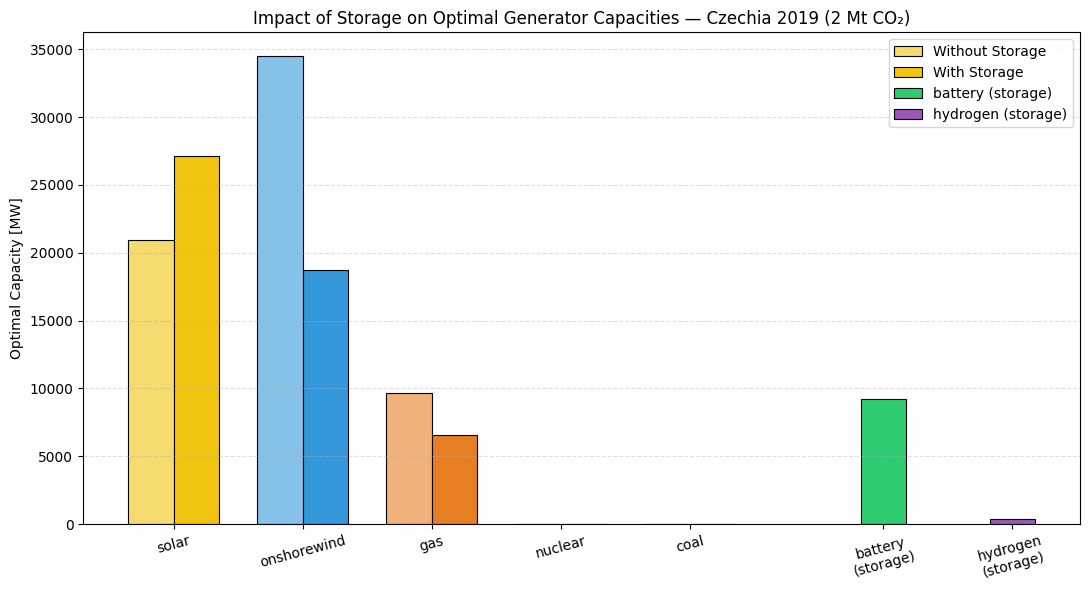

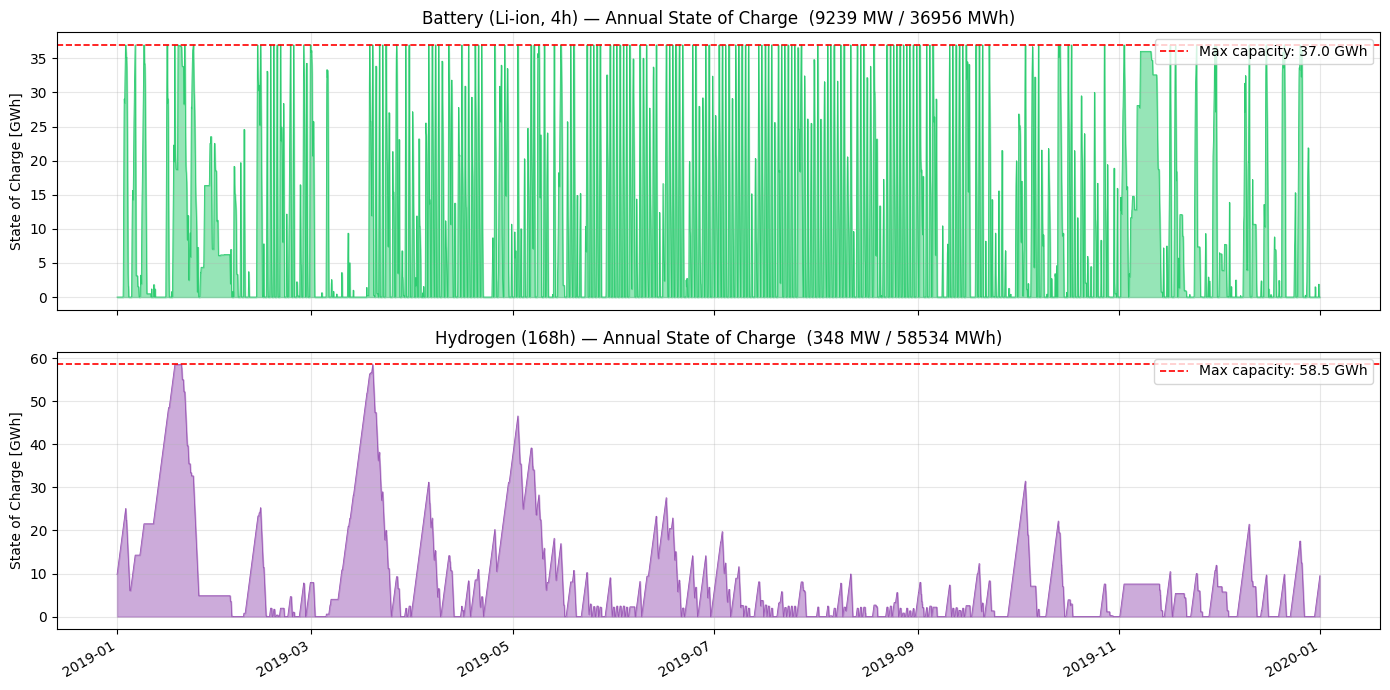

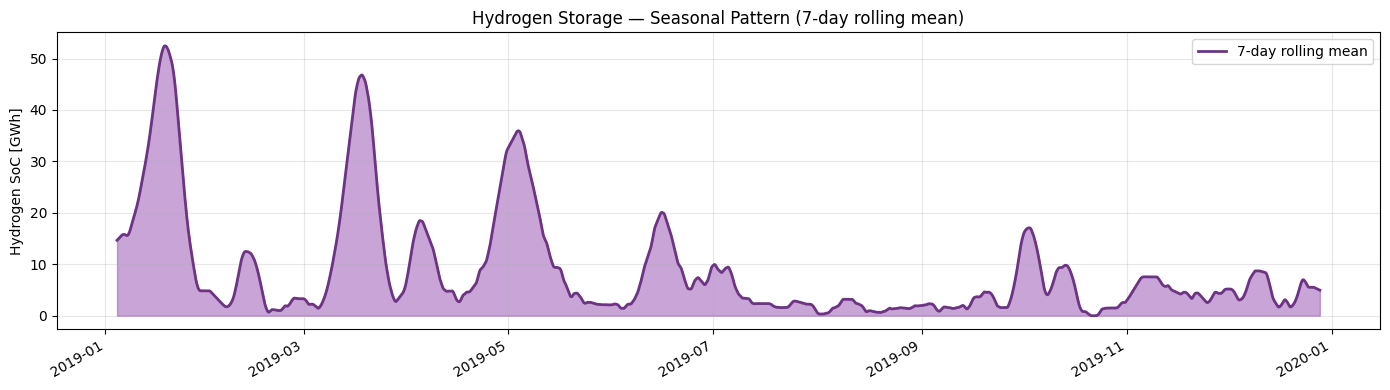

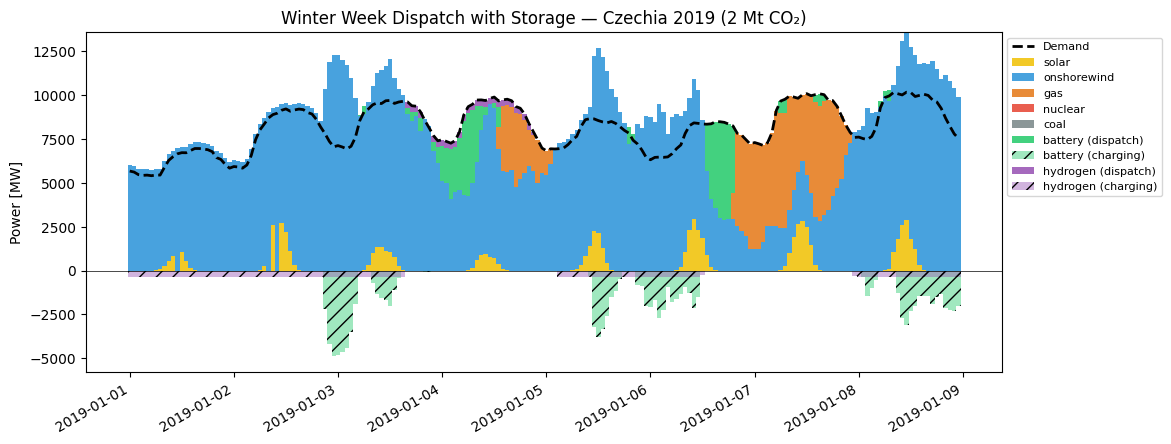

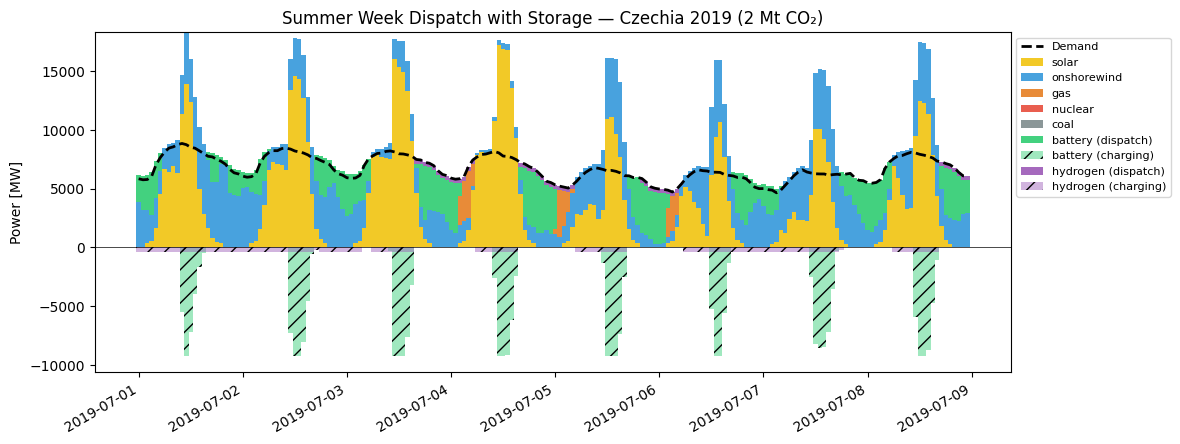

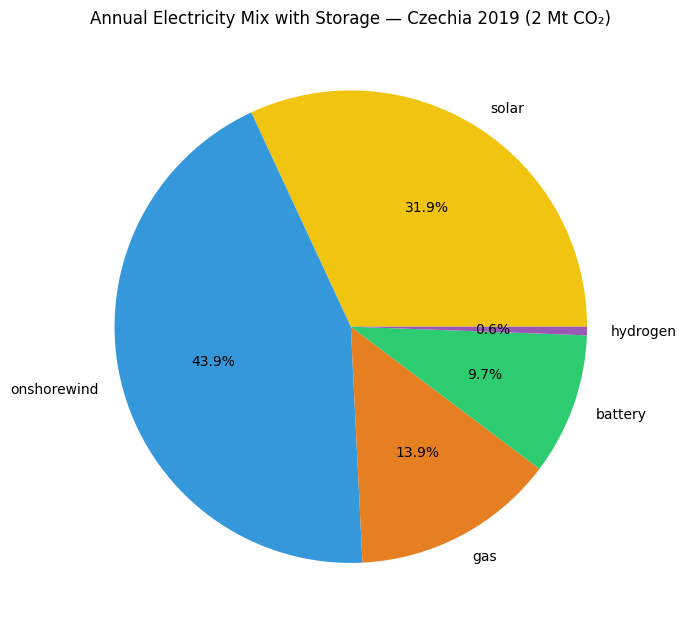


All Part C plots saved. Done!


In [ ]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import os
import numpy as np

# PART C — Storage Integration 
# --- 1. SETTINGS & DATA LOADING ---
import os
script_dir = os.getcwd()  
file_path = os.path.join(script_dir, "time_series_60min_singleindex.csv")

target_columns = [
    'utc_timestamp',
    'CZ_load_actual_entsoe_transparency',
    'CZ_solar_generation_actual',
    'CZ_wind_onshore_generation_actual'
]

print("Loading and cleaning data...")
df = pd.read_csv(file_path, usecols=target_columns, index_col=0, parse_dates=True)
df.index = df.index.tz_localize(None)

cz_2019 = df.loc['2019-01-01':'2019-12-31'].copy()
cz_2019 = cz_2019.ffill().bfill()

solar_installed_mw = 2072
wind_installed_mw  = 339
cz_2019['solar_cf'] = (cz_2019['CZ_solar_generation_actual'] / solar_installed_mw).clip(0, 1)
cz_2019['wind_cf']  = (cz_2019['CZ_wind_onshore_generation_actual'] / wind_installed_mw).clip(0, 1)

# --- 2. COST FUNCTIONS ---
def annuity(n, r):
    return r / (1. - 1. / (1. + r)**n) if r > 0 else 1 / n

discount_rate = 0.07

# --- 3. TECH DATA (same as Part A) ---
tech_data = {
    'solar':       {'inv': 425000,  'fom': 0.03, 'life': 25, 'color': "#f1c40f", 'type': 'calc'},
    'onshorewind': {'inv': 1182000, 'fom': 0.03, 'life': 25, 'color': "#3498db", 'type': 'calc'},
    'gas':         {'inv': 400000,  'fom': 0.04, 'life': 30, 'color': "#e67e22",
                    'eff': 0.39, 'co2': 0.19, 'type': 'calc'},
    'nuclear':     {'ann_cap': 6000000, 'marg': 11.5, 'avail': 0.9, 'color': "#e74c3c", 'type': 'fixed'},
    'coal':        {'ann_cap': 1500000, 'marg': 51.0,  'avail': 1.0, 'color': "#7f8c8d",
                    'co2': 0.34, 'type': 'fixed'}
}

fuel_cost_gas = 21.6
vom_gas       = 3.0

# Storage cost data — Source: DEA Technology Catalogue 2023, IRENA 2023
# Battery: Li-ion 4-hour utility scale
# Hydrogen: alkaline electrolyser + compressed tank + PEM fuel cell
storage_data = {
    'battery': {
        'inv':          600000,   # EUR/MW — combined power+energy for 4h (DEA 2023: ~150 EUR/kWh)
        'fom':          0.02,
        'life':         15,
        'eff_store':    0.95,
        'eff_dispatch': 0.95,     # round-trip = 90%
        'max_hours':    4,
        'color':        "#2ecc71",
    },
    'hydrogen': {
        'inv':          2000000,  # EUR/MW — electrolyser + tank + fuel cell (DEA 2023)
        'fom':          0.03,
        'life':         20,
        'eff_store':    0.70,     # electrolyser
        'eff_dispatch': 0.50,     # fuel cell → round-trip = 35%
        'max_hours':    168,      # ~1 week seasonal buffer
        'color':        "#9b59b6",
    }
}

# Build network
def build_network(include_storage, co2_limit_t):
    n = pypsa.Network()
    n.set_snapshots(cz_2019.index)
    n.add("Bus", "Czech Republic")

    for tech, data in tech_data.items():
        n.add("Carrier", tech, color=data['color'],
              co2_emissions=data.get('co2', 0))

    n.add("Load", "Demand", bus="Czech Republic",
          p_set=cz_2019['CZ_load_actual_entsoe_transparency'])

    for tech, data in tech_data.items():
        if data['type'] == 'calc':
            capital_cost = annuity(data['life'], discount_rate) * data['inv'] * (1 + data['fom'])
            if tech == 'gas':
                marginal_cost = (fuel_cost_gas / data['eff']) + vom_gas
                p_max_pu = 1.0
            elif tech == 'onshorewind':
                marginal_cost = 0.01
                p_max_pu = cz_2019['wind_cf']
            else:
                marginal_cost = 0.01
                p_max_pu = cz_2019['solar_cf']
        else:
            capital_cost  = data['ann_cap']
            marginal_cost = data['marg']
            p_max_pu      = data['avail']

        n.add("Generator", tech,
              bus="Czech Republic",
              carrier=tech,
              p_nom_extendable=True,
              capital_cost=capital_cost,
              marginal_cost=marginal_cost,
              p_max_pu=p_max_pu)

    n.add("GlobalConstraint", "co2_limit",
          type="primary_energy",
          carrier_attribute="co2_emissions",
          sense="<=",
          constant=co2_limit_t)

    if include_storage:
        for name, s in storage_data.items():
            ann_factor   = annuity(s['life'], discount_rate) * (1 + s['fom'])
            capital_cost = ann_factor * s['inv']   # EUR/MW 

            n.add("StorageUnit",
                  name,
                  bus="Czech Republic",
                  carrier=name,
                  capital_cost=capital_cost,
                  marginal_cost=0,
                  efficiency_store=s['eff_store'],
                  efficiency_dispatch=s['eff_dispatch'],
                  max_hours=s['max_hours'],
                  cyclic_state_of_charge=True,
                  p_nom_extendable=True)

    return n


# 4. RUN OPTIMISATIONS
CO2_CAP = 2e6  

print(f"\nRunning WITHOUT storage (CO2 cap = {CO2_CAP/1e6:.0f} Mt)...")
n_no = build_network(include_storage=False, co2_limit_t=CO2_CAP)
n_no.optimize(solver_name='highs')

print(f"Running WITH storage (CO2 cap = {CO2_CAP/1e6:.0f} Mt)...")
n_yes = build_network(include_storage=True, co2_limit_t=CO2_CAP)
n_yes.optimize(solver_name='highs')


# 5. PRINT RESULTS
print("\n" + "="*60)
print("PART C — RESULTS SUMMARY  (CO2 cap = 2 Mt)")
print("="*60)

print(f"\n{'Technology':<15} {'Without Storage':>18} {'With Storage':>15}")
print("-"*52)
for gen in n_no.generators.index:
    c_no  = n_no.generators.at[gen,  'p_nom_opt']
    c_yes = n_yes.generators.at[gen, 'p_nom_opt']
    delta = c_yes - c_no
    print(f"{gen:<15} {c_no:>14.1f} MW   {c_yes:>12.1f} MW  ({delta:+.0f} MW)")

print("\n--- Storage Capacities ---")
for su in n_yes.storage_units.index:
    p    = n_yes.storage_units.at[su, 'p_nom_opt']
    mxh  = storage_data[su]['max_hours']
    rte  = storage_data[su]['eff_store'] * storage_data[su]['eff_dispatch'] * 100
    dispatch_pos = n_yes.storage_units_t.p[su].clip(lower=0)
    cycles = dispatch_pos.sum() / max(p * mxh, 1e-6)
    print(f"  {su:<12}: {p:>8.1f} MW  | {p*mxh:>10.1f} MWh  | RTE={rte:.0f}%  | ~{cycles:.0f} cycles/yr")

obj_no  = n_no.objective  / 1e6
obj_yes = n_yes.objective / 1e6
print(f"\n--- System Cost ---")
print(f"  Without storage : {obj_no:.2f}  M EUR/year")
print(f"  With storage    : {obj_yes:.2f}  M EUR/year")
print(f"  Change          : {obj_yes-obj_no:+.2f} M EUR/year  ({(obj_yes/obj_no-1)*100:+.1f}%)")

# Check curtailment
curtailment_no  = ((n_no.generators_t.p_max_pu * n_no.generators.p_nom_opt -
                    n_no.generators_t.p)).clip(lower=0).sum().sum()
curtailment_yes = ((n_yes.generators_t.p_max_pu * n_yes.generators.p_nom_opt -
                    n_yes.generators_t.p)).clip(lower=0).sum().sum()
print(f"\n--- Annual Curtailment ---")
print(f"  Without storage : {curtailment_no/1e6:.2f}  TWh curtailed")
print(f"  With storage    : {curtailment_yes/1e6:.2f}  TWh curtailed")
print(f"  Reduction       : {(curtailment_no-curtailment_yes)/1e6:.2f} TWh saved by storage")


# 6. PLOTS
gen_colors_no  = [n_no.carriers.at[c,  "color"] for c in n_no.generators.carrier]
gen_colors_yes = [n_yes.carriers.at[c, "color"] for c in n_yes.generators.carrier]

# Plot 1: Capacity comparison 
caps_before = n_no.generators.p_nom_opt
caps_after  = n_yes.generators.p_nom_opt
storage_caps = n_yes.storage_units.p_nom_opt

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(caps_before))
w = 0.35
ax.bar(x - w/2, caps_before.values, w, label='Without Storage',
       color=[c + "99" for c in gen_colors_no],  # lighter shade
       edgecolor='black', linewidth=0.8)
ax.bar(x + w/2, caps_after.values, w, label='With Storage',
       color=gen_colors_yes, edgecolor='black', linewidth=0.8)

x2 = np.arange(len(storage_caps)) + len(caps_before) + 0.5
for i, (su, val) in enumerate(storage_caps.items()):
    ax.bar(x2[i], val, w, color=storage_data[su]['color'],
           edgecolor='black', linewidth=0.8,
           label=f"{su} (storage)")

all_x    = np.concatenate([x - w/2, x + w/2, x2])
all_labs = (list(caps_before.index) + list(caps_after.index) +
            [f"{su}\n(storage)" for su in storage_caps.index])
ax.set_xticks(np.concatenate([x, x2]))
ax.set_xticklabels(list(caps_before.index) +
                   [f"{su}\n(storage)" for su in storage_caps.index],
                   rotation=15)
ax.set_ylabel("Optimal Capacity [MW]")
ax.set_title("Impact of Storage on Optimal Generator Capacities — Czechia 2019 (2 Mt CO₂)")
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(script_dir, "partC_capacity_comparison.png"), dpi=150)
plt.show()

#Plot 2: Annual State of Charge 
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, su, label in zip(axes,
                         ['battery', 'hydrogen'],
                         ['Battery (Li-ion, 4h)', 'Hydrogen (168h)']):
    p_opt = n_yes.storage_units.at[su, 'p_nom_opt']
    soc   = n_yes.storage_units_t.state_of_charge[su]
    soc_gwh = soc / 1e3
    max_gwh = p_opt * storage_data[su]['max_hours'] / 1e3
    ax.fill_between(soc.index, soc_gwh, alpha=0.5,
                    color=storage_data[su]['color'])
    ax.plot(soc.index, soc_gwh, linewidth=0.6,
            color=storage_data[su]['color'])
    ax.axhline(max_gwh, linestyle='--', color='red', linewidth=1.2,
               label=f'Max capacity: {max_gwh:.1f} GWh')
    ax.set_ylabel("State of Charge [GWh]")
    ax.set_title(f"{label} — Annual State of Charge  ({p_opt:.0f} MW / {p_opt*storage_data[su]['max_hours']:.0f} MWh)")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(os.path.join(script_dir, "partC_state_of_charge.png"), dpi=150)
plt.show()

# Plot 3: Hydrogen seasonal rolling mean 
fig, ax = plt.subplots(figsize=(14, 4))
h2_soc     = n_yes.storage_units_t.state_of_charge['hydrogen'] / 1e3
h2_rolling = h2_soc.rolling(24*7, center=True).mean()
ax.fill_between(h2_soc.index, h2_rolling, alpha=0.55, color="#9b59b6")
ax.plot(h2_soc.index, h2_rolling, color="#6c3483", linewidth=2,
        label="7-day rolling mean")
ax.set_ylabel("Hydrogen SoC [GWh]")
ax.set_title("Hydrogen Storage — Seasonal Pattern (7-day rolling mean)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(os.path.join(script_dir, "partC_hydrogen_seasonal.png"), dpi=150)
plt.show()

# Plot 4: Dispatch with storage — Summer & Winter week 
for season, start in [("Winter", "2019-01-01"), ("Summer", "2019-07-01")]:
    end = pd.Timestamp(start) + pd.Timedelta(days=7)
    sl  = slice(start, str(end.date()))

    gen_dispatch = n_yes.generators_t.p.loc[sl]
    demand       = n_yes.loads_t.p_set.loc[sl, 'Demand']

    fig, ax = plt.subplots(figsize=(13, 5))

    bottom = pd.Series(0.0, index=gen_dispatch.index)
    for col, color in zip(gen_dispatch.columns, gen_colors_yes):
        ax.bar(gen_dispatch.index, gen_dispatch[col], bottom=bottom,
               width=1/24, color=color, label=col, alpha=0.9)
        bottom = bottom + gen_dispatch[col]

    for su in n_yes.storage_units.index:
        su_p    = n_yes.storage_units_t.p.loc[sl, su]
        su_pos  = su_p.clip(lower=0)
        su_neg  = su_p.clip(upper=0)
        c       = storage_data[su]['color']
        ax.bar(su_p.index, su_pos, bottom=bottom,
               width=1/24, color=c, label=f'{su} (dispatch)', alpha=0.9)
        ax.bar(su_p.index, su_neg,
               width=1/24, color=c, label=f'{su} (charging)',
               alpha=0.45, hatch='//')
        bottom = bottom + su_pos

    ax.plot(demand.index, demand.values, color='black',
            linewidth=2, linestyle='--', label='Demand')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel("Power [MW]")
    ax.set_title(f"{season} Week Dispatch with Storage — Czechia 2019 (2 Mt CO₂)")
    ax.legend(loc='upper right', bbox_to_anchor=(1.18, 1), fontsize=8)
    fig.autofmt_xdate()
    plt.subplots_adjust(right=0.83)
    plt.savefig(os.path.join(script_dir, f"partC_dispatch_{season.lower()}.png"),
                dpi=150)
    plt.show()

# Plot 5: Annual mix WITH storage 
total_gen = n_yes.generators_t.p.sum()
mix_vals  = total_gen.copy()
for su in n_yes.storage_units.index:
    dispatch = n_yes.storage_units_t.p[su].clip(lower=0).sum()
    mix_vals[su] = dispatch

mix_vals  = mix_vals[mix_vals > 1]
mix_colors = []
for name in mix_vals.index:
    if name in n_yes.generators.index:
        mix_colors.append(n_yes.carriers.at[n_yes.generators.at[name, 'carrier'], 'color'])
    else:
        mix_colors.append(storage_data[name]['color'])

plt.figure(figsize=(7, 7))
mix_vals.plot(kind='pie', autopct='%1.1f%%', colors=mix_colors,
              title="Annual Electricity Mix with Storage — Czechia 2019 (2 Mt CO₂)")
plt.ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(script_dir, "partC_annual_mix.png"), dpi=150)
plt.show()

print("\nAll Part C plots saved. Done!")